About Dataset
Welcome to the Retail Sales and Customer Demographics Dataset! This synthetic dataset has been meticulously crafted to simulate a dynamic retail environment, providing an ideal playground for those eager to sharpen their data analysis skills through exploratory data analysis (EDA). With a focus on retail sales and customer characteristics, this dataset invites you to unravel intricate patterns, draw insights, and gain a deeper understanding of customer behavior.

**Dataset Overview:

This dataset is a snapshot of a fictional retail landscape, capturing essential attributes that drive retail operations and customer interactions. It includes key details such as Transaction ID, Date, Customer ID, Gender, Age, Product Category, Quantity, Price per Unit, and Total Amount. These attributes enable a multifaceted exploration of sales trends, demographic influences, and purchasing behaviors.

Why Explore This Dataset?

Realistic Representation: Though synthetic, the dataset mirrors real-world retail scenarios, allowing you to practice analysis within a familiar context.
Diverse Insights: From demographic insights to product preferences, the dataset offers a broad spectrum of factors to investigate.
Hypothesis Generation: As you perform EDA, you'll have the chance to formulate hypotheses that can guide further analysis and experimentation.
Applied Learning: Uncover actionable insights that retailers could use to enhance their strategies and customer experiences.
Questions to Explore:

How does customer age and gender influence their purchasing behavior?
Are there discernible patterns in sales across different time periods?
Which product categories hold the highest appeal among customers?
What are the relationships between age, spending, and product preferences?
How do customers adapt their shopping habits during seasonal trends?
Are there distinct purchasing behaviors based on the number of items bought per transaction?
What insights can be gleaned from the distribution of product prices within each category?
i want to work on this data set now, now act like the ceo or owner of this business. include the existed eda, what are the things or questions will you expect from this dataset to be answered 

In [258]:
# import variables
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [259]:
# load the dataset
df=pd.read_csv(r'C:\Users\DELL\Documents\retails sales dataset\retail_sales_dataset.csv')

In [260]:
df.head(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [261]:
# check for null values
null_values=df.isna().sum()
null_values
# no null values found

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [262]:
# check for duplicates
df_duplicates=df.duplicated().sum()
df_duplicates
# no duplicates

0

In [263]:
# check df info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [265]:
# remove space from the column names
df.columns=df.columns.str.replace(' ','_')

In [266]:
df['Date']=pd.to_datetime(df['Date'])
# convert the date which has data type of object to datetime

## What is my total revenue per day, week, month?

In [267]:
# convert the date to weekly and monthly date
df['weekly']=df['Date'].dt.to_period('W').dt.start_time
df['monthly']=df['Date'].dt.to_period('M').dt.start_time



In [268]:
weekly_total=df.groupby('weekly')['Total_Amount'].sum()
monthly_total=df.groupby('monthly')['Total_Amount'].sum()

In [269]:
# get the moving average
weekly_moving_avg = weekly_total.rolling(window=4).mean()
monthly_moving_avg = monthly_total.rolling(window=12).mean()

## Is revenue growing or dropping over time?

Text(0.5, 1.0, 'weekly sales')

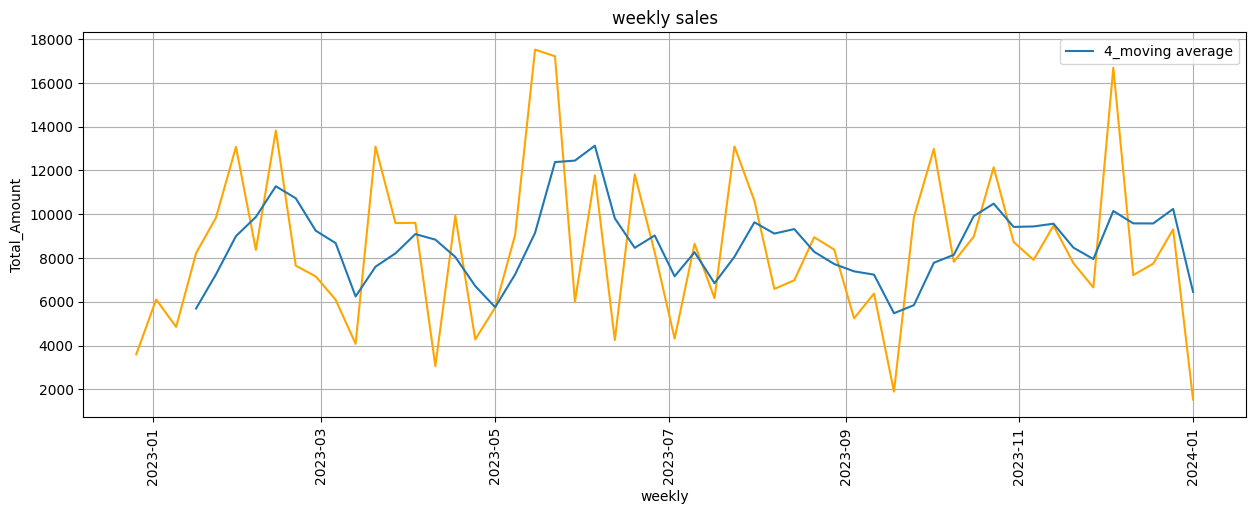

In [270]:
#plot the chart for weekly and monthly sales
plt.figure(figsize=(15,5))
sns.lineplot(weekly_total,color='orange')
plt.plot(weekly_moving_avg, label='4_moving average')

plt.legend()
plt.grid()
plt.xticks(rotation=90)
plt.title('weekly sales')

Text(0.5, 1.0, 'Monthly sales')

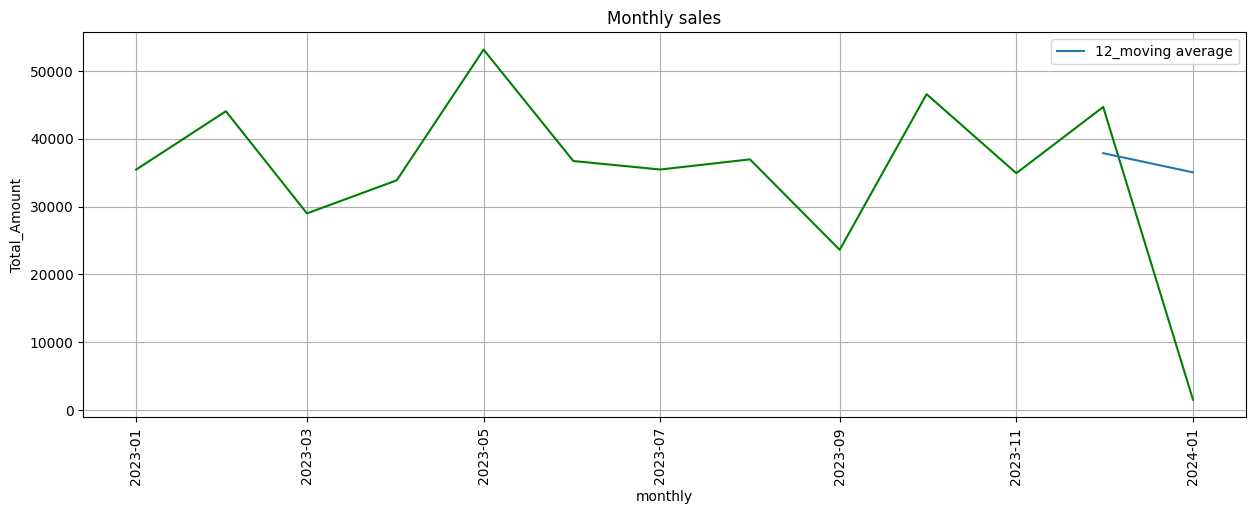

In [271]:
plt.figure(figsize=(15,5))
sns.lineplot(monthly_total,color='green')
plt.plot(monthly_moving_avg, label='12_moving average')
plt.legend()
plt.grid()
plt.xticks(rotation=90)
plt.title('Monthly sales')

Text(0.5, 1.0, 'weekly total sales')

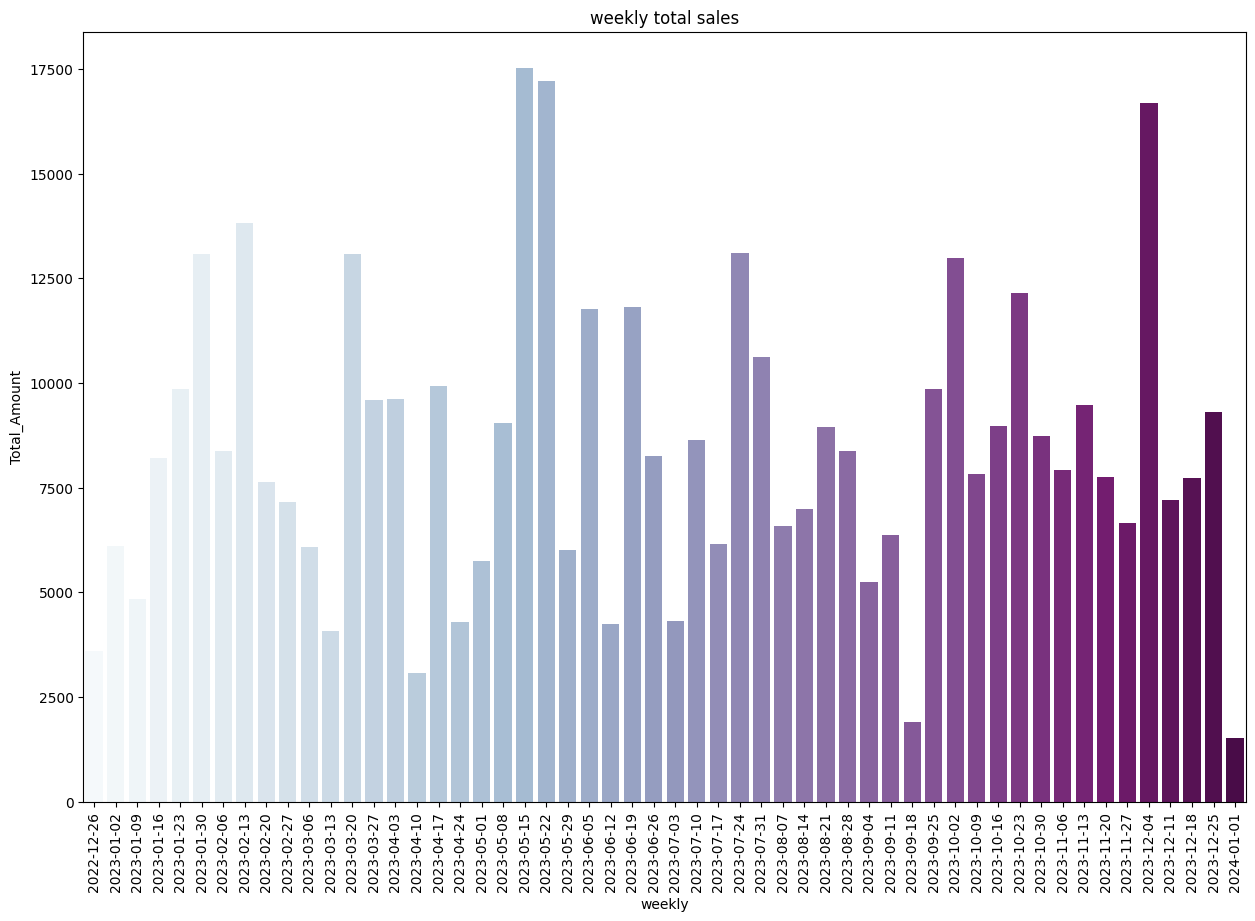

In [272]:
plt.figure(figsize=(15,10))
sns.barplot(weekly_total, label=' Total revenue per week', palette='BuPu')
plt.xticks(rotation=90)
plt.title('weekly total sales')

## Interpretation:
### revenue is dropping

# Which days generate the highest sales?

In [273]:
days_with_highest_sales=df.groupby('Date')['Total_Amount'].sum()
mean=days_with_highest_sales.mean()

mean

1321.7391304347825

Text(0.5, 1.0, 'days with highest sales')

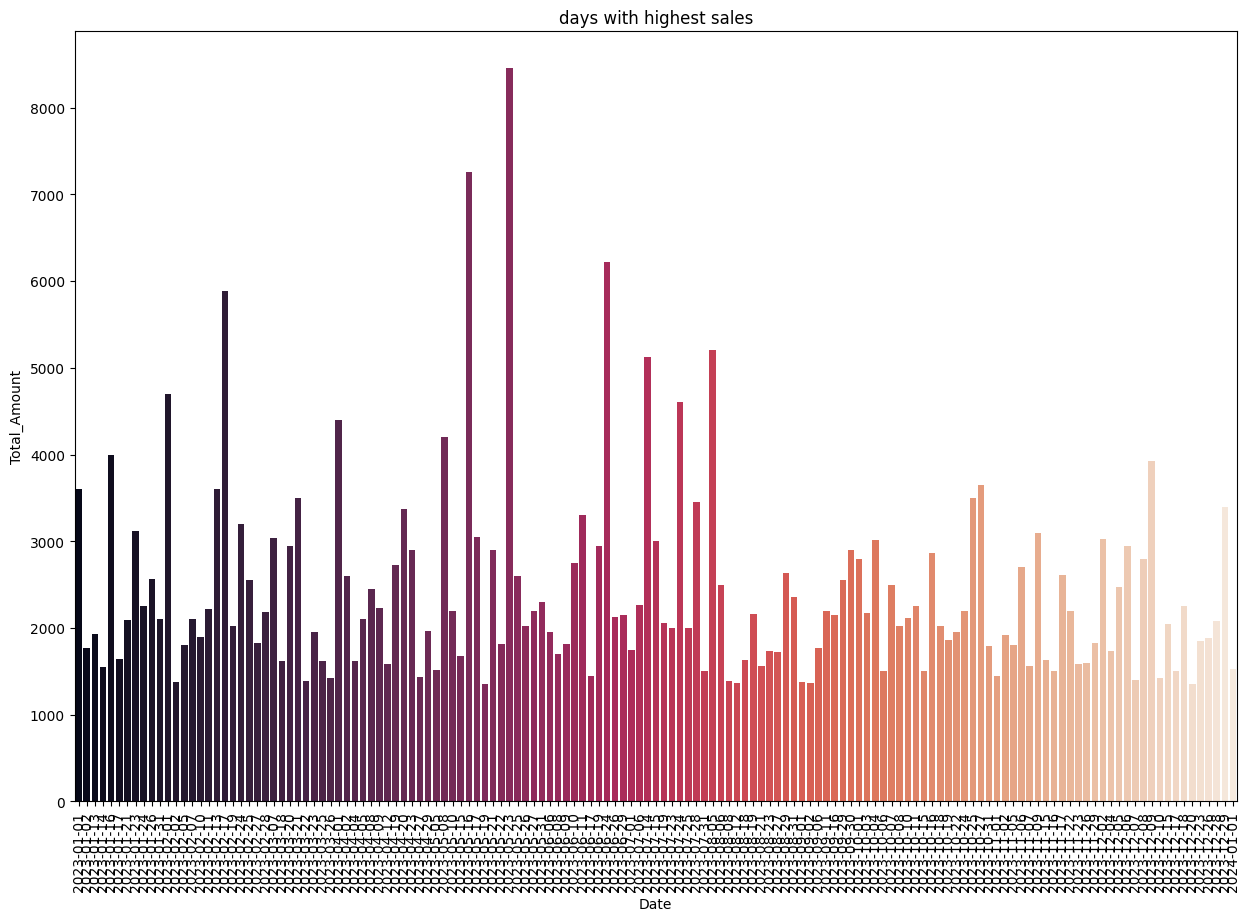

In [274]:
## days with highest sales
plt.figure(figsize=(15,10))
highest_day_sales=days_with_highest_sales[days_with_highest_sales>mean]
len(highest_day_sales)
sns.barplot(highest_day_sales, palette='rocket', label='days with highest sales')
plt.xticks(rotation=90)
plt.title('days with highest sales')


## Interpretion:
#### the business had 143 days where sales where above daily sales average. therefore 143 days generated high sales

# Months with high and low sales

In [275]:
high_weekly_sales=df.groupby('monthly')['Total_Amount'].sum()
high_weekly_sales.mean()
# to get the weeks with high sales and low sales

35076.92307692308

In [276]:
high_week_sales=high_weekly_sales[high_weekly_sales>high_weekly_sales.mean()]
low_week_sales=high_weekly_sales[high_weekly_sales<high_weekly_sales.mean()]
len(low_week_sales), len(high_week_sales)

(5, 8)

Text(0.5, 1.0, 'low monthly total sales')

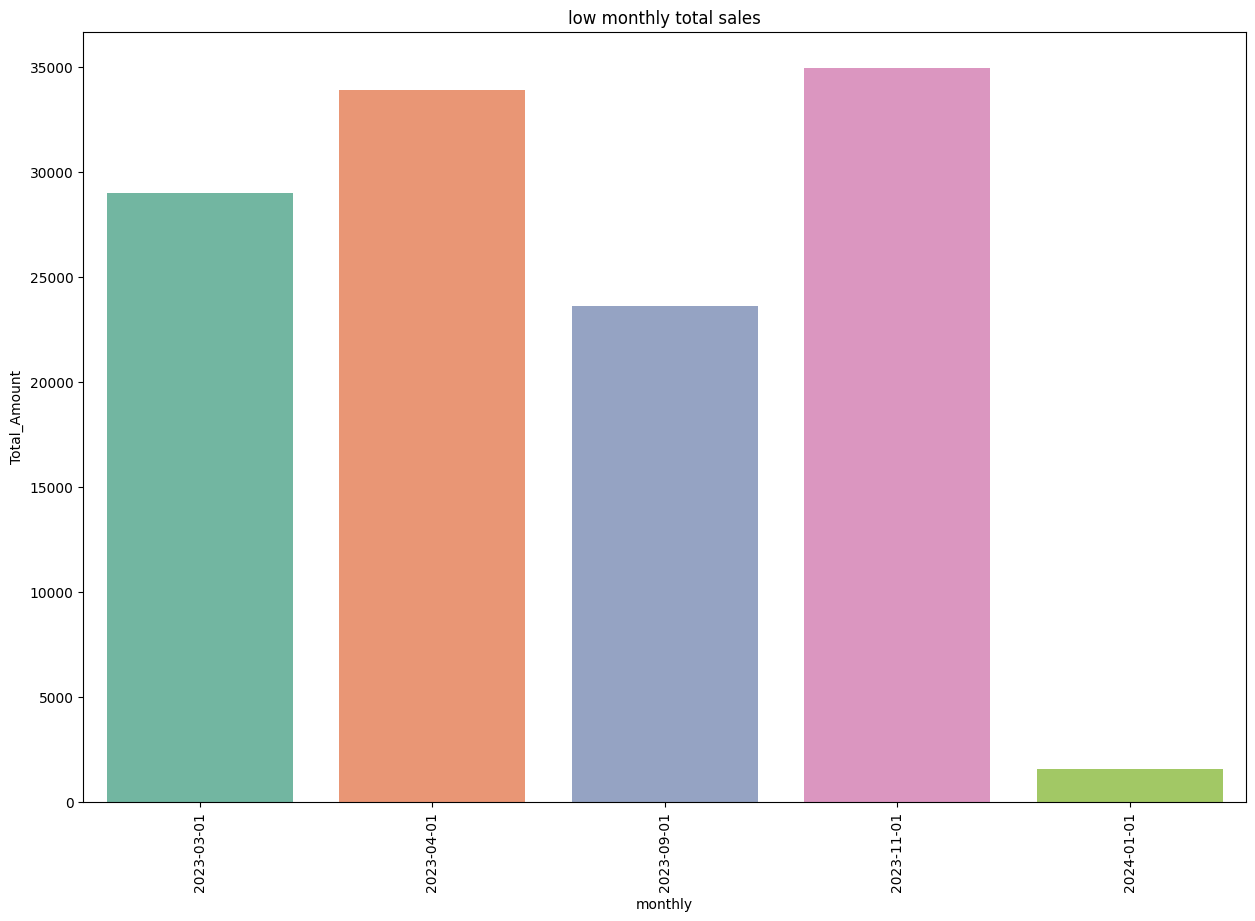

In [277]:
plt.figure(figsize=(15,10))
sns.barplot(low_week_sales, label='low monthly sales', palette='Set2')
plt.xticks(rotation=90)
plt.title('low monthly total sales')

Text(0.5, 1.0, 'High monthly total sales')

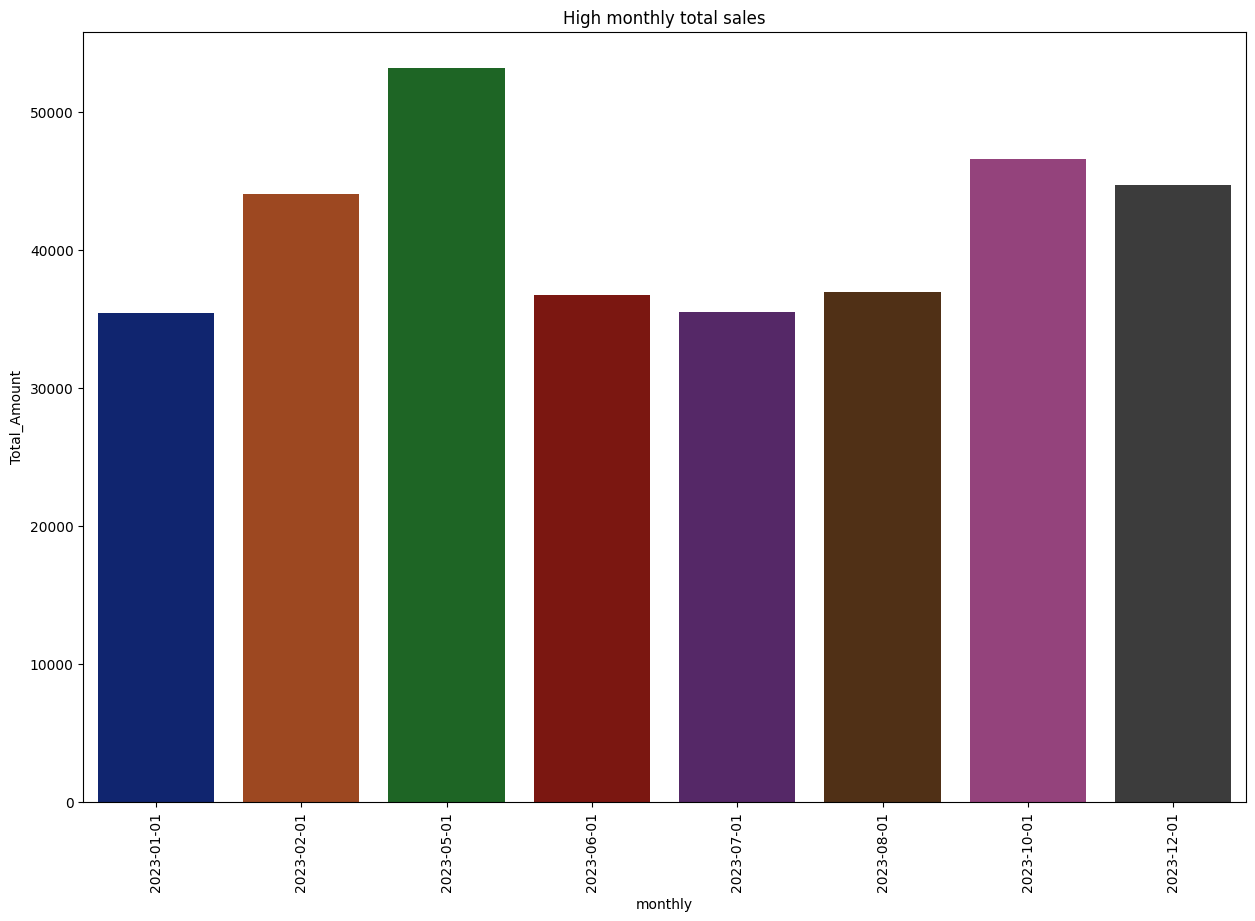

In [278]:
plt.figure(figsize=(15,10))
sns.barplot(high_week_sales, label='High monthly sales', palette='dark')
plt.xticks(rotation=90)
plt.title('High monthly total sales')

In [279]:
max_month_sales=df.groupby('monthly')['Total_Amount'].sum().reset_index()
highest_month = max_month_sales.loc[max_month_sales['Total_Amount'].idxmax()]
lowest_month = max_month_sales.loc[max_month_sales['Total_Amount'].idxmin()]
highest_month,lowest_month

(monthly         2023-05-01 00:00:00
 Total_Amount                  53150
 Name: 4, dtype: object,
 monthly         2024-01-01 00:00:00
 Total_Amount                   1530
 Name: 12, dtype: object)

### Interpretation
#### the highest sales the business made in a month was #53150 on 2023-05-01 AND  lowest is #1530 on 2024-01-01

##### 

## Interpretation
## on both the weekly and monthly chart sales are declining, both weekly and monthly sales are below the moving average


### The Business has 5 monthly sales were below their total sales average and 8 monthly sales were above the total sales average. which we can say the business is doing moderatel well on sales

# Identify stable weeks,days and months
# identify weeks, days and months with spike


In [280]:
days_with_spike=df.groupby('Date')['Total_Amount'].agg(['mean','std'])
weeks_with_spike=df.groupby('weekly')['Total_Amount'].agg(['mean','std'])
months_with_spike=df.groupby('monthly')['Total_Amount'].agg(['mean','std'])

In [281]:
#Get the correlation coeffiecient
days_with_spike['cv']=days_with_spike['std']/days_with_spike['mean']
weeks_with_spike['cv']=weeks_with_spike['std']/weeks_with_spike['mean']
months_with_spike['cv']=months_with_spike['std']/months_with_spike['mean']


In [282]:
spike_days=days_with_spike[days_with_spike['cv']>0.20]
stable_days=days_with_spike[days_with_spike['cv']<0.20]
spike_weeks=weeks_with_spike[weeks_with_spike['cv']>0.20]
stable_weeks=weeks_with_spike[weeks_with_spike['cv']<0.20]
spike_months=months_with_spike[months_with_spike['cv']>0.20]
stable_months=months_with_spike[months_with_spike['cv']<0.20]
len(spike_days), len(stable_days),len(spike_weeks),len(stable_weeks),len(stable_months),len(spike_months)

(260, 18, 54, 0, 0, 13)

## Interpretation:
The sales volatility analysis showed that sales were highly unpredictable throughout the year. This level of fluctuation makes it difficult for the business to accurately forecast demand, which can lead to inventory planning challenges such as overstocking during slow periods and stockouts during periods of high demand

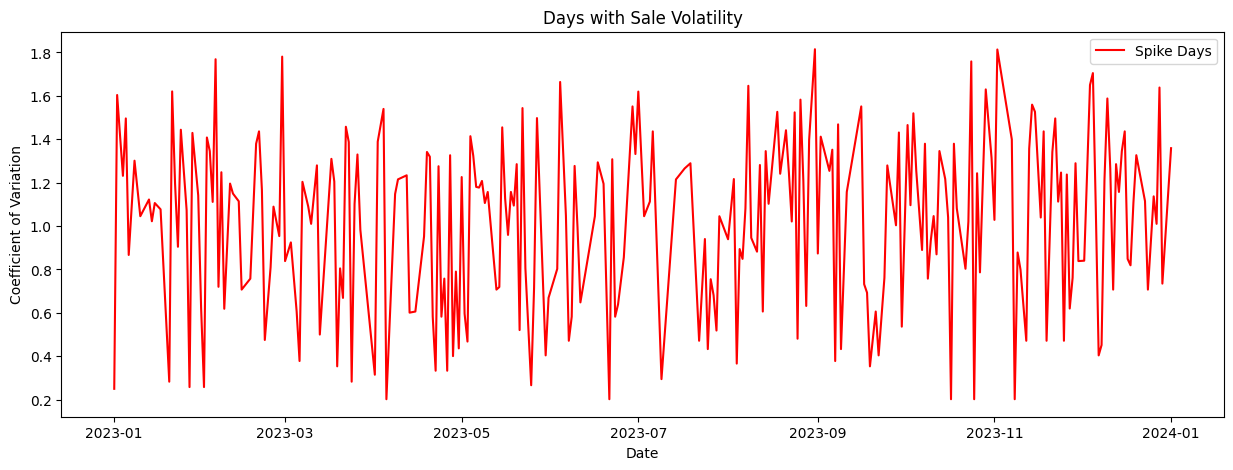

In [283]:
plt.figure(figsize=(15,5))
plt.plot(spike_days.index, spike_days['cv'], color='red', label='Spike Days')
plt.title('Days with Sale Volatility')
plt.xlabel('Date')
plt.ylabel('Coefficient of Variation')
plt.legend()
plt.show()


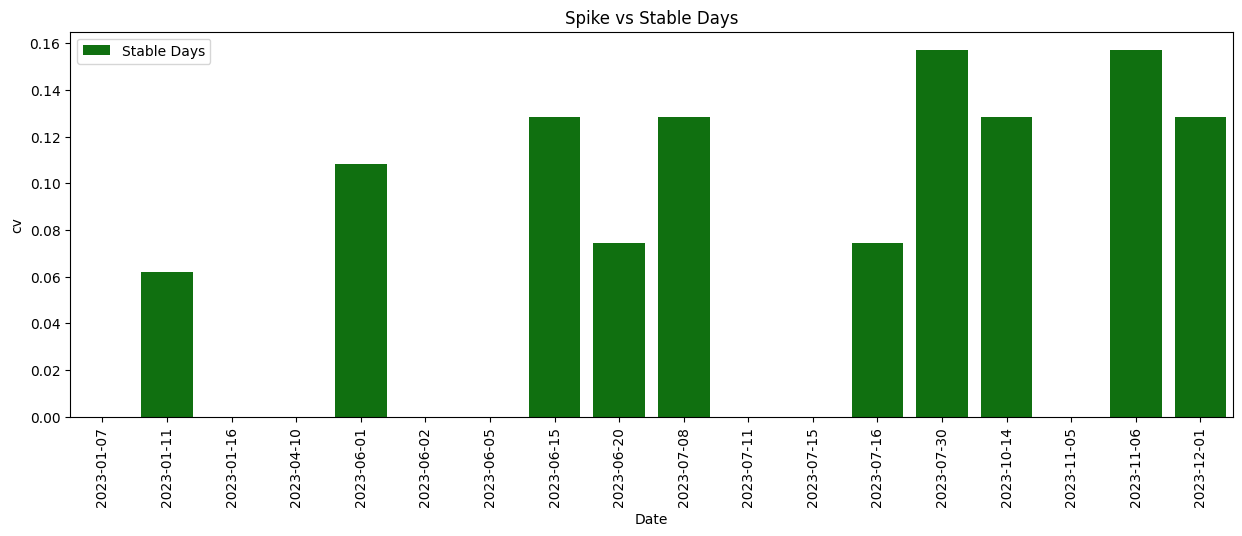

In [284]:
plt.figure(figsize=(15,5))
sns.barplot(x=stable_days.index, y=stable_days['cv'], color='green', label='Stable Days')
plt.legend()
plt.title("Spike vs Stable Days")
plt.xticks(rotation=90)
plt.show()

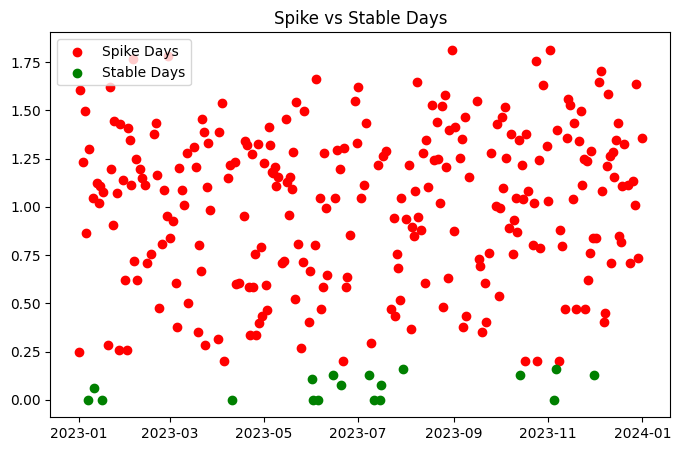

In [285]:
plt.figure(figsize=(8,5))

plt.scatter(spike_days.index, spike_days['cv'], color='red', label='Spike Days')
plt.scatter(stable_days.index, stable_days['cv'], color='green', label='Stable Days')

plt.legend()
plt.title("Spike vs Stable Days")
plt.show()

# 2.  Product Performance

### 2i) Which product categories generate the most revenue?

In [287]:
category_with_high_revenue=df.groupby('Product_Category')['Total_Amount'].sum().reset_index()
category_with_high_revenue.sort_values(by='Total_Amount',ascending=False)

,Product_Category,Total_Amount
2,Electronics,156905
1,Clothing,155580
0,Beauty,143515


Text(0.5, 1.0, 'Product Category vs Revenue')

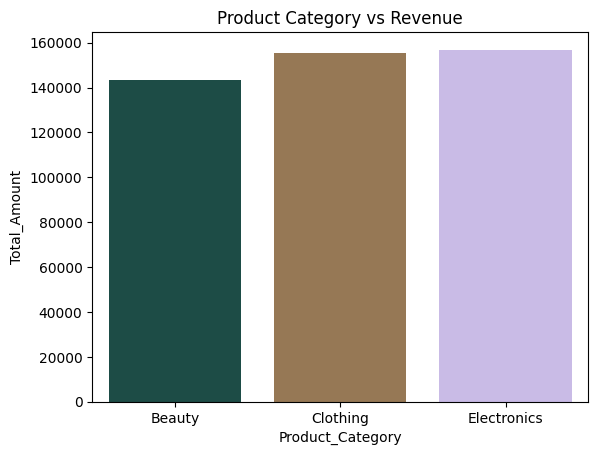

In [288]:
sns.barplot(x=category_with_high_revenue['Product_Category'],y=category_with_high_revenue['Total_Amount'], palette='cubehelix')
plt.title("Product Category vs Revenue")

## interpretations:
### this business has 3 category of products the sell, which include:
### beauty, clothing and electronics
### from the analysis, electronic generate more revenue

# 2ii) Which categories are frequently bought but low revenue?

In [289]:
frequent_purchase=df.groupby('Product_Category')['Quantity'].sum()
frequent_purchase

Product_Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64

### Interpretation:
#### clothings are frequently purchase but the revenue is not as high as electronics

# 2iii) Which products are dead stock (rarely bought)?

In [ ]:
# none
## but beauty are the lowest customer purchase
df.groupby('Product_Category')['Quantity'].sum()

Product_Category
Beauty         771
Clothing       894
Electronics    849
Name: Quantity, dtype: int64

# none

# 3.  Customer Behavior (Who is my real customer?)

# 3i) Who spends more: male or female customers?

In [291]:
spend=df.groupby('Gender')['Total_Amount'].sum().reset_index().sort_values(by='Total_Amount',ascending=False)
spend


,Gender,Total_Amount
0,Female,232840
1,Male,223160


Text(0.5, 1.0, 'who spends the most')

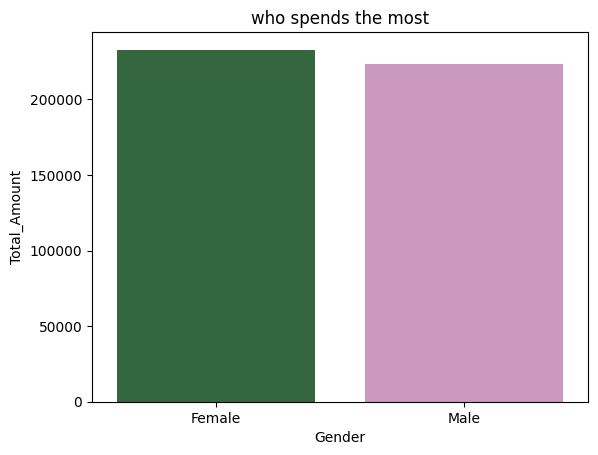

In [292]:
sns.barplot(x=spend['Gender'],y=spend['Total_Amount'], palette='cubehelix', label='who spends the most')
plt.title('who spends the most')

## Interpretation:
### from the analysis, the female customer buys the most

# 3ii) Which age group spends the most?

In [293]:
age_spendder=df.groupby('Age')['Total_Amount'].sum().reset_index().sort_values(by='Total_Amount', ascending=False)
# filter the high age spenders
high_age_spender=age_spendder[age_spendder>=age_spendder.mean()]
low_age_spender=age_spendder[age_spendder<=age_spendder.mean()]


Text(0.5, 1.0, 'Age group that spend the least')

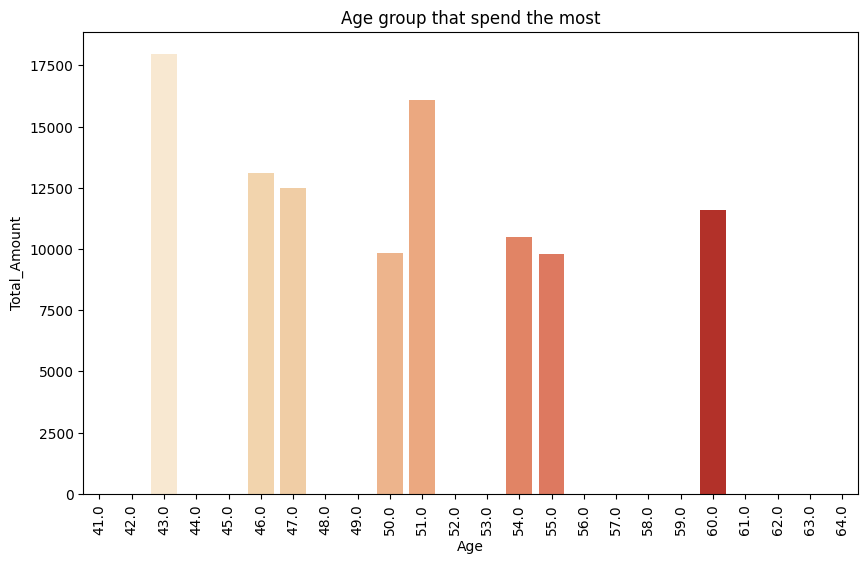

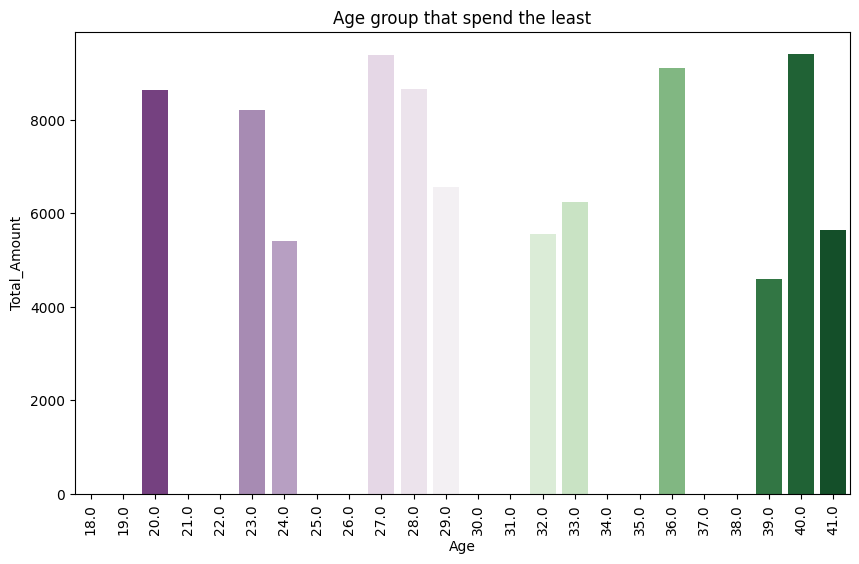

In [294]:
#plot the chart
plt.figure(figsize=(10,6))
sns.barplot(x=high_age_spender['Age'],y=high_age_spender['Total_Amount'], label='Age group that spend the most', palette='OrRd')
plt.xticks(rotation=90)
plt.title('Age group that spend the most')

plt.figure(figsize=(10,6))
sns.barplot(x=low_age_spender['Age'],y=low_age_spender['Total_Amount'], label='Age group that spend the least', palette='PRGn')
plt.xticks(rotation=90)
plt.title('Age group that spend the least')

# Interpretation:
## Age 43 and above spend above the total amount average on this business
## Age 40 and below spend below total amount averge

# Time-Based Behavior (When people buy)


## 4i) Are weekends stronger than weekdays?

In [333]:
# Create a new column for day names
df['day_name'] = df['Date'].dt.day_name()

In [335]:
## to get he weekend and weekdays
df['day_type'] = df['Date'].dt.day_name().replace({
    'Monday': 'Weekday',
    'Tuesday': 'Weekday',
    'Wednesday': 'Weekday',
    'Thursday': 'Weekday',
    'Friday': 'Weekday',
    'Saturday': 'Weekend',
    'Sunday': 'Weekend'
})

In [339]:
weekend=df.groupby('day_type')['Total_Amount'].sum().reset_index()
weekend

,day_type,Total_Amount
0,Weekday,318585
1,Weekend,137415


Text(0.5, 1.0, 'when do people buy')

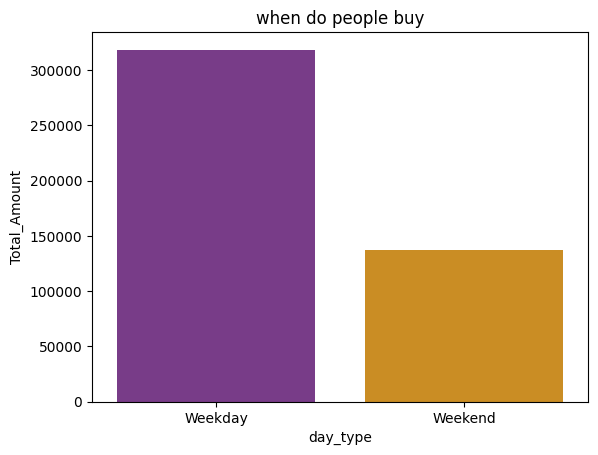

In [340]:
sns.barplot(x=weekend['day_type'],y=weekend['Total_Amount'],label='When do people buy', palette='CMRmap')
plt.title('when do people buy')

## interpretation:
### people buy more on weekdays than weekends

# 6. 🧍 Customer Value Segmentation (Who are my VIP customers?)

# 7. 📦 Pricing Strategy Insights

## 7i) Do higher-priced products sell less (expected or not)?

In [297]:
high_priced=df.groupby('Price_per_Unit')['Total_Amount'].sum().reset_index().sort_values(by='Total_Amount',ascending=False)
high_priced

,Price_per_Unit,Total_Amount
4,500,247500
3,300,155400
2,50,26700
1,30,13350
0,25,13050


Text(0.5, 1.0, 'product prices that sells the most')

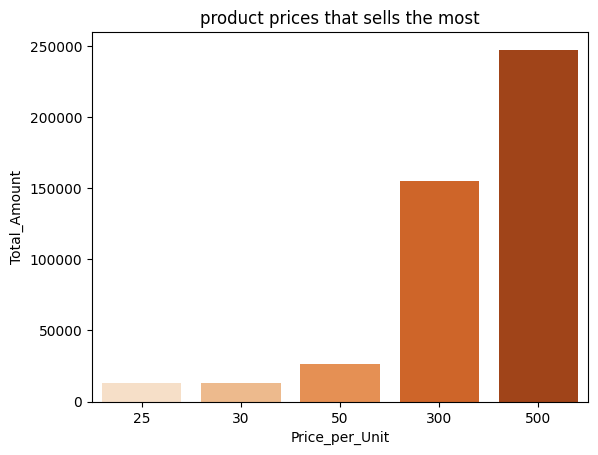

In [298]:
sns.barplot(x=high_priced['Price_per_Unit'],y=high_priced['Total_Amount'], palette='Oranges')
plt.title('product prices that sells the most')

# Interpretation:
High price products sells more than low priced product

## 7ii) Which price range sells most?

### Interpretation:
#### the price range that sells the most is from #300 to #500

In [299]:
df.groupby('Product_Category')['Price_per_Unit'].sum()

Product_Category
Beauty         56505
Clothing       61175
Electronics    62210
Name: Price_per_Unit, dtype: int64

# Customer segmentation

In [300]:
df2=df.copy()

In [301]:
# drop some columns
df2.drop(['Transaction_ID','Customer_ID','Date','weekly','monthly'],axis=1,inplace=True)

In [302]:
# conver object values to numeric
from sklearn .preprocessing import LabelEncoder
le=LabelEncoder()
df2['Gender']=le.fit_transform(df2['Gender'])
df2['Product_Category']=le.fit_transform(df2['Product_Category'])

In [303]:
df2.head()

,Gender,Age,Product_Category,Quantity,Price_per_Unit,Total_Amount
0,1,34,0,3,50,150
1,0,26,1,2,500,1000
2,1,50,2,1,30,30
3,1,37,1,1,500,500
4,1,30,0,2,50,100


In [304]:
# feature selection
x=df2[['Gender', 'Age', 'Product_Category', 'Quantity', 'Price_per_Unit',
       'Total_Amount']]



In [305]:
#scale the data
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler(feature_range=(0,1))
x_scaled=scaler.fit_transform(x)

In [306]:
# determin the k value
from sklearn.cluster import KMeans
error=[]
for i in range(2,10):
    kmeans=KMeans(n_clusters=i,random_state=42)
    kmeans.fit(x_scaled)
    error.append(kmeans.inertia_)

Text(0.5, 1.0, 'elbow method')

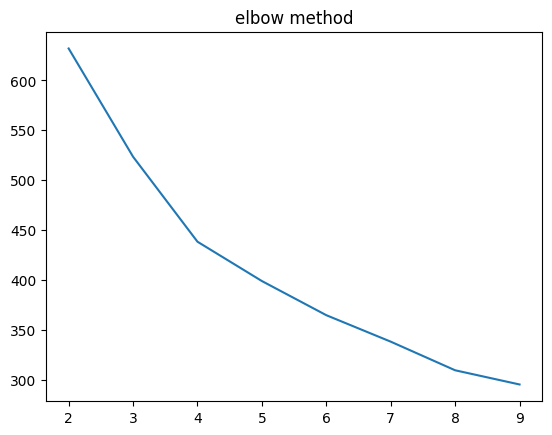

In [307]:
# plot the the elbow
plt.plot(range(2,10),error)
plt.title('elbow method')

In [308]:
# 2 will be selected for k because the elbow sit right on it

In [309]:
from sklearn.metrics import silhouette_score
silhouette = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=0)
    labels = kmeans.fit_predict(x_scaled)

    score = silhouette_score(x_scaled, labels)
    silhouette.append(score)

silhouette

[0.28654075517077704,
 0.2683882367604858,
 0.30007608860384405,
 0.27226405670902837,
 0.23842688319559163,
 0.2384361834893119,
 0.2597715711163125,
 0.2684385582312009]

In [310]:
# from the eblow method and silhouette method, 4 is the k
# load the model
kmeans=KMeans(n_clusters=i, random_state=42)
kmeans.fit(x_scaled)

,n_clusters,9
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [311]:
# get the kmeans labels and clusters
cluster=kmeans.labels_
centriod=kmeans.cluster_centers_

In [312]:
# add the cluster to dataset
df2['cluster']=cluster
df2

,Gender,Age,Product_Category,Quantity,Price_per_Unit,Total_Amount,cluster
0,1,34,0,3,50,150,3
1,0,26,1,2,500,1000,5
2,1,50,2,1,30,30,0
3,1,37,1,1,500,500,7
4,1,30,0,2,50,100,0
...,...,...,...,...,...,...,...
995,1,62,1,1,50,50,0
996,1,52,0,3,30,90,3
997,0,23,0,4,25,100,6
998,0,36,2,3,50,150,1


In [313]:
# views the segments
grouping=df2.groupby('cluster').mean()
grouping

,Gender,Age,Product_Category,Quantity,Price_per_Unit,Total_Amount
cluster,,,,,,
0,1.0,42.321839,1.068966,1.482759,49.568966,66.896552
1,0.0,39.980892,1.713376,2.146497,52.866242,93.216561
2,0.0,39.739726,0.547945,3.452055,390.410959,1350.684932
3,1.0,41.425373,1.000000,3.559701,36.044776,128.507463
4,1.0,37.400000,0.400000,3.058824,412.941176,1237.647059
5,0.0,41.180556,0.680556,1.458333,422.222222,615.277778
6,0.0,43.761006,0.364780,2.823899,34.811321,98.144654
7,1.0,43.360825,1.721649,2.278351,407.216495,918.556701
8,0.0,40.632653,2.000000,3.163265,389.795918,1218.367347


In [314]:
list(zip(le.classes_, le.transform(le.classes_)))
# to view the classes on how lable encoder transform these object values

[('Beauty', 0), ('Clothing', 1), ('Electronics', 2)]

In [315]:
grouping
# this is the customer segmentation

,Gender,Age,Product_Category,Quantity,Price_per_Unit,Total_Amount
cluster,,,,,,
0,1.0,42.321839,1.068966,1.482759,49.568966,66.896552
1,0.0,39.980892,1.713376,2.146497,52.866242,93.216561
2,0.0,39.739726,0.547945,3.452055,390.410959,1350.684932
3,1.0,41.425373,1.000000,3.559701,36.044776,128.507463
4,1.0,37.400000,0.400000,3.058824,412.941176,1237.647059
5,0.0,41.180556,0.680556,1.458333,422.222222,615.277778
6,0.0,43.761006,0.364780,2.823899,34.811321,98.144654
7,1.0,43.360825,1.721649,2.278351,407.216495,918.556701
8,0.0,40.632653,2.000000,3.163265,389.795918,1218.367347


# Interpretaion:
### cluster 0:
 mostly female
Age 42 and above
 buy mostly clothing ,low quantity,at low price
 Toal amount is very low,
#### insight:
Older female customers buying low-quantity, low-cost clothing items.
### cluster 1:
mostly males
Age 40 
buy a mix of clothing and electronic
moderate quantity at low price
low spenders
#### insights:
Male customers buying mostly clothing with some electronics, low-value purchases.
### Cluster 2:
age 39
buy mix of clothing and beauty
high quantity at high price
#### insights:
High-value male customers purchasing expensive items in bulk (premium segment).
### cluster 3:
female
age 41
buy only clothing at a very high quantity at low price
low spenders
#### insights:
Female bulk buyers of low-cost clothing items.
### cluster 4:
female
buy clothing and beauty
high quantity at high price, very high valued spenders
#### Insight:
Young female premium beauty shoppers (high-value segment).
### cluster:5
male
age 41
puchases beauty and a mix of clothing
low quantity at high price
#### Insight:
Male customers buying expensive items but in small quantities (premium selective buyers).
### cluster 6:
male
age 43
mostly beauty with little clothing,
moderate quantity at a very low price
#### Insight:
Older male customers buying low-cost beauty products.
### cluster 7:
female
age 43
buys clothing and electronic
moderate quantity at high price
#### Insight:
High-income female electronics/clothing shoppers.
### cluster 8:
male
age 40
buy only electronics
high quantity and very high price
#### Insight:
Male electronics buyers with high spending and high quantity.



# BUSINESS SUMMARY 

there are basically  4 major customer groups hidden inside 8 clusters:

## 1. Premium Electronics Buyers
Cluster 2, 7, 8
High price + high total
Main revenue drivers
## 2. Premium Beauty Buyers
Cluster 4
Young females
High-value segment
## 3. Low-cost Clothing Buyers
Cluster 0, 3
Low spending, high quantity in cluster 3
## 4. Budget / Mixed Buyers
Cluster 1, 5, 6
Low to medium spend
Less profitable

# Daily Sales forecast

In [316]:
from xgboost import XGBRegressor


In [318]:
df4=df.copy()
# duplicate the tables
#conver object variables
df4['Gender']=le.fit_transform(df4['Gender'])
df4['Product_Category']=le.fit_transform(df4['Product_Category'])

In [319]:
df4['year'] = df4['Date'].dt.year
df4['month'] = df4['Date'].dt.month
df4['day'] = df4['Date'].dt.day
# because raw date cant be transformed in scaler, this is to extract the day, month and year individually


In [321]:
x=df4[['Gender', 'Age','Product_Category', 'day','month','year']]
y=df4['Total_Amount']

In [322]:
# drop columns
df4.drop(['Customer_ID','Transaction_ID'], axis=1,inplace=True)

<Axes: >

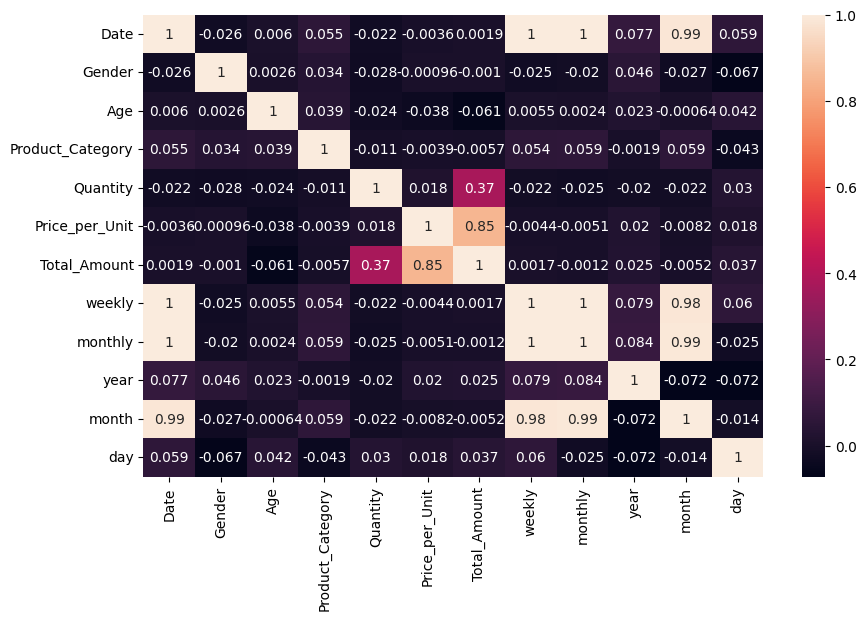

In [323]:
plt.figure(figsize=(10,6))
df_corr=df4.corr()
sns.heatmap(df_corr,annot=True)

In [324]:
# split the dataset
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [325]:
x_train.shape,x_test.shape

((800, 6), (200, 6))

In [326]:
# scale the data
x_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
model=XGBRegressor(random_state=42)
model.fit(x_scaled,y_train)
model.score(x_scaled,y_train)

0.9814655780792236

In [327]:
from sklearn.metrics import r2_score
# predict x_test
ypred=model.predict(x_test_scaled)



In [328]:
# check accuracy
score=r2_score(y_test,ypred)
score

-0.68169105052948

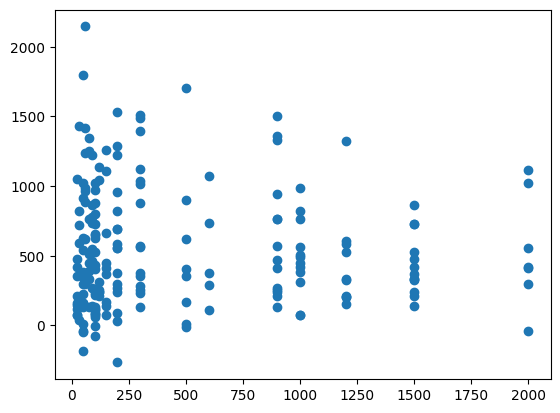

In [329]:
# model is overfitted
plt.scatter(x=y_test,y=ypred,label='actual vs predicted')

# model testing

In [331]:
model.predict(scaler.transform([[1,	34,	0,24,11	,2023]]))

array([143.2498], dtype=float32)